# InsightFace Lookalike Classification: Javier Bardem vs Jeffrey Dean Morgan

This notebook evaluates the InsightFace face recognition model's ability to distinguish between two celebrity lookalikes: **Javier Bardem** and **Jeffrey Dean Morgan**.

**Evaluation Design:**
- **Binary classification**: Every image is classified as exactly one of the two people (no "None" / unknown class)
- **Classification rule**: Assign the label of the reference with the **highest cosine similarity** (no threshold)
- **Goal**: Measure how well the model separates two visually similar individuals


In [1]:
import datetime
import json
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# InsightFace imports
from insightface.app import FaceAnalysis
import onnxruntime as ort

BASE_DIR = Path("/app")
TESTSET_PATH = BASE_DIR / "testsets/Lookalike-Testset_testset.json"
REFERENCES_PATH = BASE_DIR / "data/references.json"
OUTPUT_ROOT = BASE_DIR / "image_outputs"

# Only these two identities
TARGET_IDENTITIES = ["Javier Bardem", "Jeffrey Dean Morgan"]

# Create experiment output directory
EXPERIMENT_DIR = OUTPUT_ROOT / f"insightface_lookalike_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

DET_SIZE = (640, 640)

print(f"✓ Setup complete")
print(f"\nPaths:")
print(f"  Output directory: {EXPERIMENT_DIR}")
print(f"  Test set: {TESTSET_PATH}")
print(f"  References: {REFERENCES_PATH}")
print(f"\nClassification:")
print(f"  Identities: {TARGET_IDENTITIES}")
print(f"  Rule: Each image → label with max cosine similarity (no threshold, no None class)")

# Evaluation parameters (matching other experiment notebooks)
F1_BETA = 0.4                      # F-beta score parameter
FIXED_RECALL_LEVEL = 0.95           # Fixed recall level for precision@recall
FIXED_PRECISION_LEVEL = 0.95        # Fixed precision level for recall@precision


✓ Setup complete

Paths:
  Output directory: /app/image_outputs/insightface_lookalike_20260310_231658
  Test set: /app/testsets/Lookalike-Testset_testset.json
  References: /app/data/references.json

Classification:
  Identities: ['Javier Bardem', 'Jeffrey Dean Morgan']
  Rule: Each image → label with max cosine similarity (no threshold, no None class)


## Load Test Set

Load the Lookalike testset and verify its structure (each image labelled as exactly one person).


In [2]:
# Load test set
with open(TESTSET_PATH, "r", encoding="utf-8") as f:
    test_items = json.load(f)

print(f"✓ Loaded {len(test_items)} test images")

# Verify: each image should have exactly 1 label from TARGET_IDENTITIES
label_counts = Counter()
for item in test_items:
    labels = item.get("labels", [])
    assert len(labels) == 1, f"Expected 1 label, got {labels} for {item.get('path')}"
    assert labels[0] in TARGET_IDENTITIES, f"Unexpected label {labels[0]}"
    label_counts[labels[0]] += 1

print(f"\nTest set label distribution:")
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} images ({count/len(test_items)*100:.1f}%)")


✓ Loaded 1080 test images

Test set label distribution:
  Javier Bardem: 465 images (43.1%)
  Jeffrey Dean Morgan: 615 images (56.9%)


## Initialize InsightFace

Initialize the InsightFace model for face detection and embedding extraction.


In [3]:
# Initialize InsightFace
available = ort.get_available_providers()
prefer_cuda = "CUDAExecutionProvider" in available
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if prefer_cuda else ["CPUExecutionProvider"]
ctx_id = 0 if prefer_cuda else -1

try:
    app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
    app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
    print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
except Exception as e:
    if prefer_cuda:
        print(f"⚠️  GPU init failed ({e}); retrying on CPU...")
        providers = ["CPUExecutionProvider"]
        ctx_id = -1
        app = FaceAnalysis(allowed_modules=["detection", "recognition"], providers=providers)
        app.prepare(ctx_id=ctx_id, det_size=DET_SIZE)
        print(f"✓ InsightFace initialized with providers={providers}, ctx_id={ctx_id}")
    else:
        raise


Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvid

## Build Reference Embeddings

Extract face embeddings from the reference images for Javier Bardem and Jeffrey Dean Morgan.


In [4]:
# Load references and filter to our two identities
with open(REFERENCES_PATH, "r", encoding="utf-8") as f:
    all_references = json.load(f)

# Build reference embeddings for our two people
reference_db = {}  # {name: [np.ndarray embeddings]}

for ref in all_references:
    name = ref.get("name")
    if name not in TARGET_IDENTITIES:
        continue

    reference_db[name] = []
    for img_ref in ref.get("reference_images", []):
        img_path_str = img_ref.get("image_path", "")
        img_path = BASE_DIR / img_path_str

        # Handle the misspelled filename for Javier Bardem
        if not img_path.exists() and "Bardem" in name:
            alt_path = img_path.parent / "HavierBardem.jpg"
            if alt_path.exists():
                print(f"  ⚠️  Using alternate path: {alt_path.name} (original {img_path.name} not found)")
                img_path = alt_path

        if not img_path.exists():
            print(f"❌ Reference image not found: {img_path}")
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            print(f"❌ Failed to load: {img_path}")
            continue

        faces = app.get(img)
        if not faces:
            print(f"⚠️  No faces detected in reference: {img_path}")
            continue

        # Use the largest detected face (highest area bounding box)
        best_face = max(faces, key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]))
        reference_db[name].append(best_face.normed_embedding)
        print(f"  ✓ {name}: extracted embedding from {img_path.name}")

print(f"\n✓ Reference embeddings ready:")
for name, embs in reference_db.items():
    print(f"  {name}: {len(embs)} embedding(s)")

assert len(reference_db) == 2, f"Expected 2 identities, got {len(reference_db)}"


/opt/venv/lib/python3.12/site-packages/insightface/utils/face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  ✓ Javier Bardem: extracted embedding from JavierBardem.jpg
  ✓ Jeffrey Dean Morgan: extracted embedding from JeffreyDeanMorgan.jpg

✓ Reference embeddings ready:
  Javier Bardem: 1 embedding(s)
  Jeffrey Dean Morgan: 1 embedding(s)


In [5]:
def classify_image(img_path, app, reference_db):
    """
    Classify an image as one of the two lookalike identities.

    For every detected face, compute cosine similarity to each reference.
    The image-level prediction is the identity with the highest similarity
    across all detected faces. If no face is detected, return the label
    with the highest reference norm score (fallback: first identity).

    Returns:
        dict with keys:
          - predicted_label (str)
          - best_similarity (float)
          - scores (dict {identity: best_similarity})
          - n_faces (int)
          - margin (float): difference between top-1 and top-2 similarity
    """
    img = cv2.imread(str(img_path))
    if img is None:
        # Can't load image — fall back
        first_id = list(reference_db.keys())[0]
        return {
            "predicted_label": first_id,
            "best_similarity": 0.0,
            "scores": {n: 0.0 for n in reference_db},
            "n_faces": 0,
            "margin": 0.0,
        }

    faces = app.get(img)
    if not faces:
        first_id = list(reference_db.keys())[0]
        return {
            "predicted_label": first_id,
            "best_similarity": 0.0,
            "scores": {n: 0.0 for n in reference_db},
            "n_faces": 0,
            "margin": 0.0,
        }

    # Compute per-identity best similarity across all faces
    identity_best = {name: -1.0 for name in reference_db}
    for face in faces:
        emb = face.normed_embedding
        for name, ref_embs in reference_db.items():
            for ref_emb in ref_embs:
                sim = float(np.dot(emb, ref_emb))
                if sim > identity_best[name]:
                    identity_best[name] = sim

    predicted_label = max(identity_best, key=identity_best.get)
    sorted_scores = sorted(identity_best.values(), reverse=True)
    margin = sorted_scores[0] - sorted_scores[1] if len(sorted_scores) > 1 else sorted_scores[0]

    return {
        "predicted_label": predicted_label,
        "best_similarity": identity_best[predicted_label],
        "scores": identity_best,
        "n_faces": len(faces),
        "margin": margin,
    }


## Run Evaluation

Classify every test image and collect predictions, ground-truth labels, similarity scores, and margins.


In [6]:
print("=" * 80)
print("EVALUATING ON LOOKALIKE TESTSET")
print("=" * 80)

y_true_labels = []     # ground-truth label per image
y_pred_labels = []     # predicted label per image
all_scores = []        # {identity: similarity} per image
all_margins = []       # margin between top-1 and top-2 per image
no_face_count = 0
processing_errors = []

for item in tqdm(test_items, desc="Classifying"):
    img_rel_path = item.get("path", "")
    img_abs_path = BASE_DIR / img_rel_path
    gt_label = item["labels"][0]

    try:
        result = classify_image(img_abs_path, app, reference_db)
        y_true_labels.append(gt_label)
        y_pred_labels.append(result["predicted_label"])
        all_scores.append(result["scores"])
        all_margins.append(result["margin"])
        if result["n_faces"] == 0:
            no_face_count += 1
    except Exception as e:
        processing_errors.append((img_rel_path, str(e)))

print(f"\n✓ Evaluation complete")
print(f"  Images evaluated: {len(y_true_labels)}")
print(f"  Images with no face detected: {no_face_count}")
if processing_errors:
    print(f"  ❌ Processing errors: {len(processing_errors)}")
    for path, err in processing_errors[:5]:
        print(f"     {path}: {err}")


EVALUATING ON LOOKALIKE TESTSET


Classifying: 100%|██████████| 1080/1080 [06:23<00:00,  2.82it/s]


✓ Evaluation complete
  Images evaluated: 1080
  Images with no face detected: 2


## Overall Metrics

Compute accuracy, precision, recall, F1, and other binary classification metrics.


In [7]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, cohen_kappa_score,
    matthews_corrcoef, balanced_accuracy_score, roc_auc_score, roc_curve, auc,
    fbeta_score, precision_recall_curve,
)

y_true = np.array(y_true_labels)
y_pred = np.array(y_pred_labels)

# ── Core binary metrics ──────────────────────────────────────────────────────
accuracy  = accuracy_score(y_true, y_pred)
balanced_acc = balanced_accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1_weighted        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
kappa   = cohen_kappa_score(y_true, y_pred)
mcc     = matthews_corrcoef(y_true, y_pred)

# F-beta (0.4) — consistent with other experiment notebooks
f04_macro = fbeta_score(y_true, y_pred, beta=F1_BETA, average="macro", zero_division=0)
f04_weighted = fbeta_score(y_true, y_pred, beta=F1_BETA, average="weighted", zero_division=0)

# ROC AUC (macro) — using score_diff for binary case
score_diff_overall = np.array([sd for sd in results_df["score_bardem"].values - results_df["score_morgan"].values]) if "results_df" in dir() else np.zeros(len(y_true))
# Note: roc_auc_val is computed later in cell 18, so we compute here too
y_binary_overall = (y_true == "Javier Bardem").astype(int)
try:

    from sklearn.preprocessing import LabelEncoder
    _le = LabelEncoder().fit(y_true)
    roc_auc_macro = float(roc_auc_score(_le.transform(y_true), _le.transform(y_pred), average="macro"))
except ValueError:
    roc_auc_macro = 0.0

# Recall@Precision=0.95 (macro) using score_diff
# Note: This requires continuous scores; computed in more detail in later cells

print("=" * 90)
print("OVERALL CLASSIFICATION METRICS")
print("=" * 90)
print(f"\n  Accuracy:              {accuracy:.4f}")
print(f"  Balanced Accuracy:     {balanced_acc:.4f}")
print(f"  Precision (macro):     {precision_macro:.4f}")
print(f"  Recall (macro):        {recall_macro:.4f}")
print(f"  F1 Score (macro):      {f1_macro:.4f}")
print(f"  Precision (weighted):  {precision_weighted:.4f}")
print(f"  Recall (weighted):     {recall_weighted:.4f}")
print(f"  F1 Score (weighted):   {f1_weighted:.4f}")
print(f"  Cohen's Kappa:         {kappa:.4f}")
print(f"  Matthews Corr Coeff:   {mcc:.4f}")
print(f"  F0.4 Score (macro):    {f04_macro:.4f}")
print(f"  F0.4 Score (weighted): {f04_weighted:.4f}")
print(f"  ROC AUC (macro):       {roc_auc_macro:.4f}")

print(f"\n{'─' * 90}")
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=TARGET_IDENTITIES, digits=4))


OVERALL CLASSIFICATION METRICS

  Accuracy:              0.9861
  Balanced Accuracy:     0.9873
  Precision (macro):     0.9847
  Recall (macro):        0.9873
  F1 Score (macro):      0.9859
  Precision (weighted):  0.9864
  Recall (weighted):     0.9861
  F1 Score (weighted):   0.9861
  Cohen's Kappa:         0.9718
  Matthews Corr Coeff:   0.9720
  F0.4 Score (macro):    0.9850
  F0.4 Score (weighted): 0.9863
  ROC AUC (macro):       0.9873

──────────────────────────────────────────────────────────────────────────────────────────
Classification Report:
                     precision    recall  f1-score   support

      Javier Bardem     0.9727    0.9957    0.9841       465
Jeffrey Dean Morgan     0.9967    0.9789    0.9877       615

           accuracy                         0.9861      1080
          macro avg     0.9847    0.9873    0.9859      1080
       weighted avg     0.9864    0.9861    0.9861      1080



✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/confusion_matrix.png


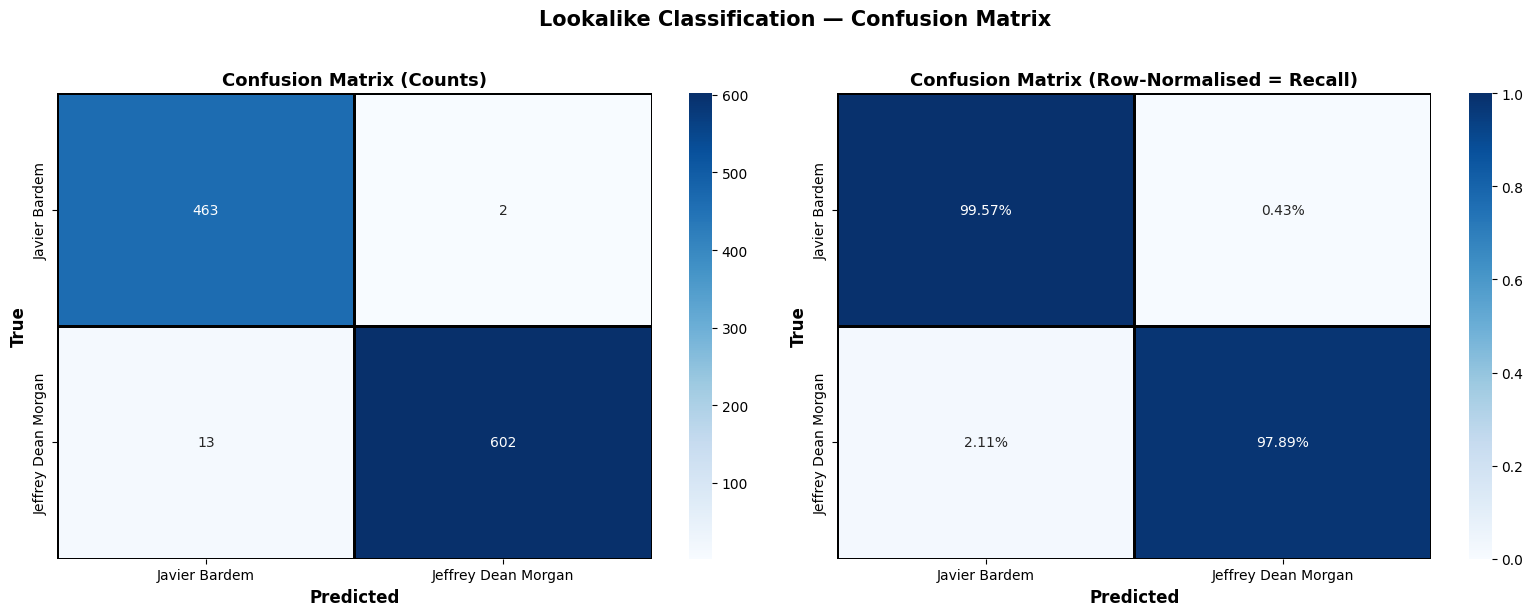

In [8]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=TARGET_IDENTITIES)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_IDENTITIES,
            yticklabels=TARGET_IDENTITIES, ax=axes[0], linewidths=1, linecolor='black')
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=13, fontweight='bold')

# Normalised (row-wise → recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=TARGET_IDENTITIES,
            yticklabels=TARGET_IDENTITIES, ax=axes[1], linewidths=1, linecolor='black',
            vmin=0, vmax=1)
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Row-Normalised = Recall)', fontsize=13, fontweight='bold')

plt.suptitle('Lookalike Classification — Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
cm_path = EXPERIMENT_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {cm_path}")
plt.show()


# Similarity Score Analysis

Examine the distribution of similarity scores and decision margins to understand model confidence.


In [9]:
# Build a DataFrame with per-image details
results_df = pd.DataFrame({
    "true_label": y_true_labels,
    "pred_label": y_pred_labels,
    "correct": [t == p for t, p in zip(y_true_labels, y_pred_labels)],
    "score_bardem": [s["Javier Bardem"] for s in all_scores],
    "score_morgan": [s["Jeffrey Dean Morgan"] for s in all_scores],
    "margin": all_margins,
})
results_df["max_score"] = results_df[["score_bardem", "score_morgan"]].max(axis=1)

print(f"Prediction summary:")
print(f"  Correct: {results_df['correct'].sum()} / {len(results_df)} ({results_df['correct'].mean()*100:.1f}%)")
print(f"\nSimilarity score statistics:")
print(results_df[["score_bardem", "score_morgan", "margin", "max_score"]].describe().round(4))


Prediction summary:
  Correct: 1065 / 1080 (98.6%)

Similarity score statistics:
       score_bardem  score_morgan     margin  max_score
count     1080.0000     1080.0000  1080.0000  1080.0000
mean         0.3105        0.3793     0.4620     0.5759
std          0.2192        0.2795     0.1318     0.1374
min         -0.1020       -0.0372     0.0000     0.0000
25%          0.1245        0.0920     0.3930     0.5201
50%          0.1854        0.4383     0.4779     0.5957
75%          0.5528        0.6488     0.5397     0.6610
max          0.7066        0.8590     0.7905     0.8590


✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/similarity_distributions.png


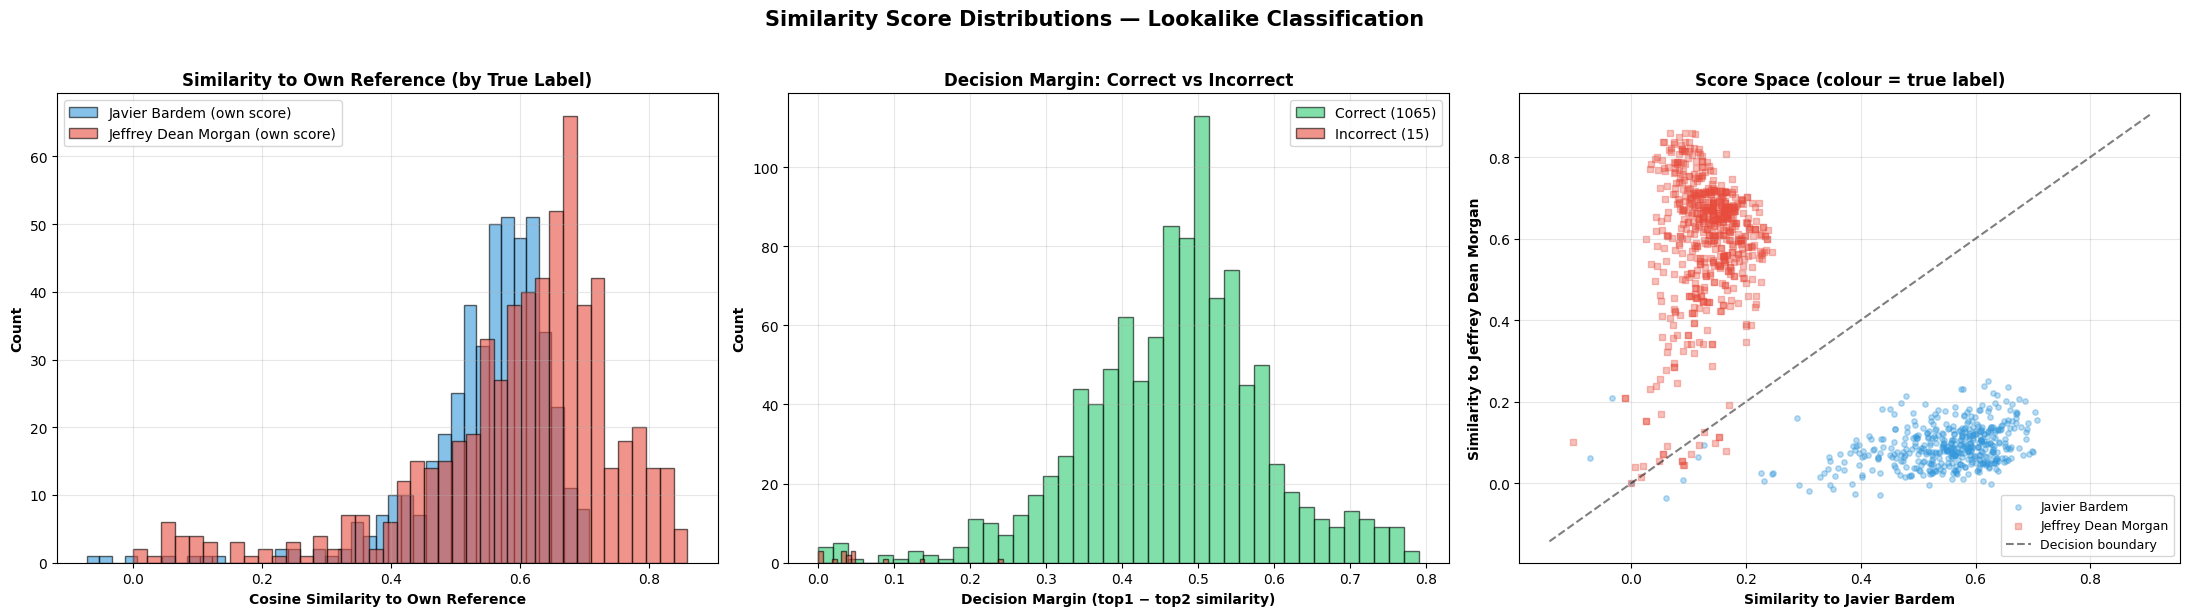

In [10]:
# ── Similarity score distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Score distribution by TRUE label
ax = axes[0]
for label, color in zip(TARGET_IDENTITIES, ['#3498db', '#e74c3c']):
    mask = results_df["true_label"] == label
    col = "score_bardem" if label == "Javier Bardem" else "score_morgan"
    ax.hist(results_df.loc[mask, col], bins=40, alpha=0.6, label=f'{label} (own score)', color=color, edgecolor='black')
ax.set_xlabel('Cosine Similarity to Own Reference', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Similarity to Own Reference (by True Label)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. Margin distribution: correct vs incorrect
ax = axes[1]
correct = results_df.loc[results_df["correct"], "margin"]
incorrect = results_df.loc[~results_df["correct"], "margin"]
ax.hist(correct, bins=40, alpha=0.6, label=f'Correct ({len(correct)})', color='#2ecc71', edgecolor='black')
ax.hist(incorrect, bins=40, alpha=0.6, label=f'Incorrect ({len(incorrect)})', color='#e74c3c', edgecolor='black')
ax.set_xlabel('Decision Margin (top1 − top2 similarity)', fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Decision Margin: Correct vs Incorrect', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. Score scatter: Bardem score vs Morgan score
ax = axes[2]
for label, marker, color in zip(TARGET_IDENTITIES, ['o', 's'], ['#3498db', '#e74c3c']):
    mask = results_df["true_label"] == label
    ax.scatter(results_df.loc[mask, "score_bardem"], results_df.loc[mask, "score_morgan"],
               alpha=0.35, s=15, marker=marker, color=color, label=label)
# Decision boundary
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='Decision boundary')
ax.set_xlabel('Similarity to Javier Bardem', fontweight='bold')
ax.set_ylabel('Similarity to Jeffrey Dean Morgan', fontweight='bold')
ax.set_title('Score Space (colour = true label)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Similarity Score Distributions — Lookalike Classification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
dist_path = EXPERIMENT_DIR / "similarity_distributions.png"
plt.savefig(dist_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {dist_path}")
plt.show()


✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/roc_curve.png


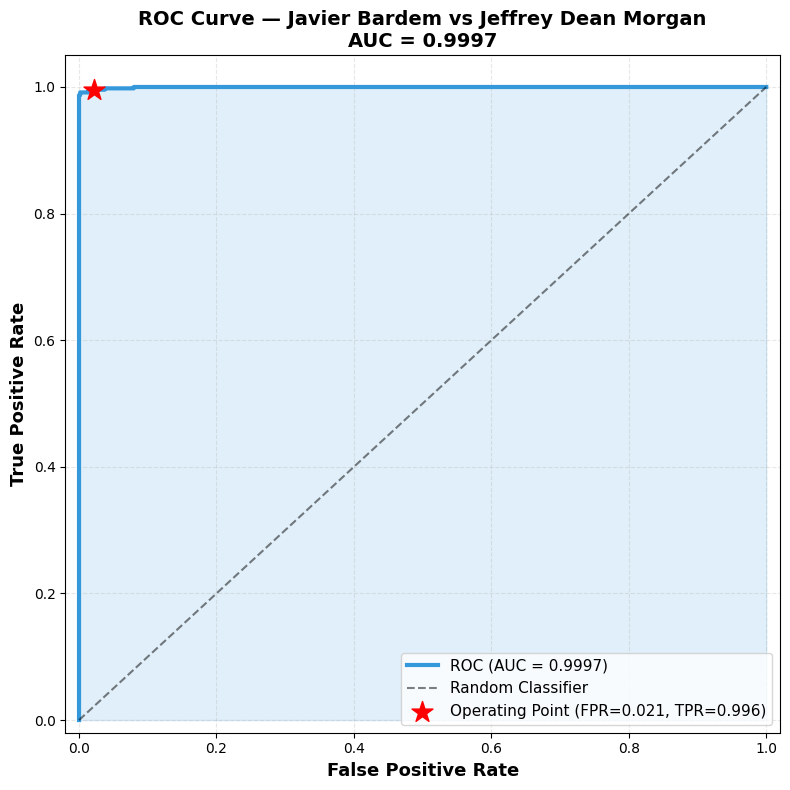


ROC AUC: 0.9997


In [11]:
# ── ROC Curve (binary: Javier Bardem = positive class) ────────────────────────
# Score difference: score_bardem - score_morgan → higher = more likely Bardem
score_diff = results_df["score_bardem"].values - results_df["score_morgan"].values
y_binary = (y_true == "Javier Bardem").astype(int)

fpr, tpr, thresholds_roc = roc_curve(y_binary, score_diff)
roc_auc_val = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(fpr, tpr, linewidth=3, color='#3498db', label=f'ROC (AUC = {roc_auc_val:.4f})')
ax.fill_between(fpr, tpr, alpha=0.15, color='#3498db')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')

# Mark operating point (threshold = 0, i.e. max-similarity decision)
pred_binary = (score_diff >= 0).astype(int)
op_tpr = recall_score(y_binary, pred_binary)
op_fpr_val = 1 - recall_score(1 - y_binary, 1 - pred_binary)
ax.scatter(op_fpr_val, op_tpr, s=250, color='red', marker='*', zorder=5,
           label=f'Operating Point (FPR={op_fpr_val:.3f}, TPR={op_tpr:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title(f'ROC Curve — Javier Bardem vs Jeffrey Dean Morgan\nAUC = {roc_auc_val:.4f}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

plt.tight_layout()
roc_path = EXPERIMENT_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {roc_path}")
plt.show()

print(f"\nROC AUC: {roc_auc_val:.4f}")


# Per-Class Performance & Error Analysis

Detailed breakdown of performance for each identity and analysis of misclassified images.


In [12]:
# ── Per-class metrics ─────────────────────────────────────────────────────────
print("=" * 90)
print("PER-CLASS METRICS")
print("=" * 90)

per_class = {}
for label in TARGET_IDENTITIES:
    mask_true = y_true == label
    mask_pred = y_pred == label
    tp = int(np.sum(mask_true & mask_pred))
    fp = int(np.sum(~mask_true & mask_pred))
    fn = int(np.sum(mask_true & ~mask_pred))
    tn = int(np.sum(~mask_true & ~mask_pred))
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    beta2 = F1_BETA ** 2
    f04 = (1 + beta2) * prec * rec / (beta2 * prec + rec) if (prec + rec) > 0 else 0
    acc = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    per_class[label] = {"TP": tp, "FP": fp, "FN": fn, "TN": tn,
                        "Precision": prec, "Recall": rec, "F1": f1, "F0.4": f04, "Accuracy": acc,
                        "Support": tp + fn}

pcdf = pd.DataFrame(per_class).T
print(pcdf.to_string())

# ── Error analysis ───────────────────────────────────────────────────────────
errors = results_df[~results_df["correct"]].copy()
print(f"\n{'─' * 90}")
print(f"ERROR ANALYSIS  ({len(errors)} misclassified images)")
print(f"{'─' * 90}")

for label in TARGET_IDENTITIES:
    err_sub = errors[errors["true_label"] == label]
    print(f"\n  {label} misclassified as {TARGET_IDENTITIES[1] if label == TARGET_IDENTITIES[0] else TARGET_IDENTITIES[0]}: {len(err_sub)}")
    if len(err_sub) > 0:
        print(f"    Margin stats (low margin = hard example):")
        print(f"      mean={err_sub['margin'].mean():.4f}  median={err_sub['margin'].median():.4f}  "
              f"max={err_sub['margin'].max():.4f}  min={err_sub['margin'].min():.4f}")


PER-CLASS METRICS
                        TP    FP    FN     TN  Precision    Recall        F1      F0.4  Accuracy  Support
Javier Bardem        463.0  13.0   2.0  602.0   0.972689  0.995699  0.984060  0.975799  0.986111    465.0
Jeffrey Dean Morgan  602.0   2.0  13.0  463.0   0.996689  0.978862  0.987695  0.994191  0.986111    615.0

──────────────────────────────────────────────────────────────────────────────────────────
ERROR ANALYSIS  (15 misclassified images)
──────────────────────────────────────────────────────────────────────────────────────────

  Javier Bardem misclassified as Jeffrey Dean Morgan: 2
    Margin stats (low margin = hard example):
      mean=0.1891  median=0.1891  max=0.2434  min=0.1349

  Jeffrey Dean Morgan misclassified as Javier Bardem: 13
    Margin stats (low margin = hard example):
      mean=0.0333  median=0.0347  max=0.0871  min=0.0000


✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/per_class_performance.png


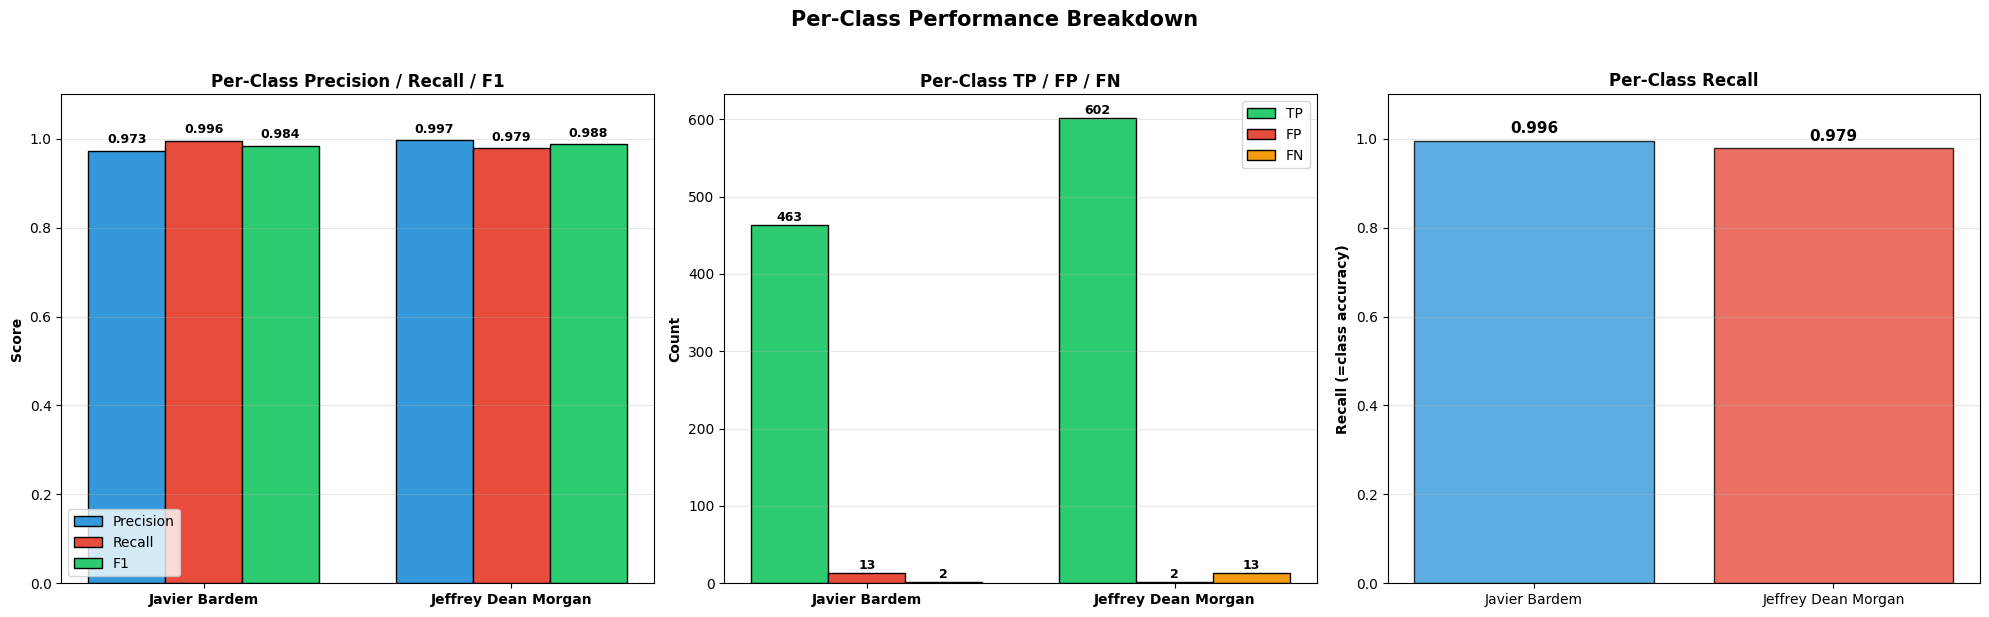

In [13]:
# ── Per-class performance bar chart ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Precision / Recall / F1 per class
ax = axes[0]
x = np.arange(len(TARGET_IDENTITIES))
w = 0.25
precs = [per_class[c]["Precision"] for c in TARGET_IDENTITIES]
recs  = [per_class[c]["Recall"] for c in TARGET_IDENTITIES]
f1s   = [per_class[c]["F1"] for c in TARGET_IDENTITIES]

bars1 = ax.bar(x - w, precs, w, label='Precision', color='#3498db', edgecolor='black')
bars2 = ax.bar(x,     recs,  w, label='Recall',    color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + w, f1s,   w, label='F1',        color='#2ecc71', edgecolor='black')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(TARGET_IDENTITIES, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. TP / FP / FN counts
ax = axes[1]
tps = [per_class[c]["TP"] for c in TARGET_IDENTITIES]
fps = [per_class[c]["FP"] for c in TARGET_IDENTITIES]
fns = [per_class[c]["FN"] for c in TARGET_IDENTITIES]
bars1 = ax.bar(x - w, tps, w, label='TP', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x,     fps, w, label='FP', color='#e74c3c', edgecolor='black')
bars3 = ax.bar(x + w, fns, w, label='FN', color='#f39c12', edgecolor='black')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(TARGET_IDENTITIES, fontweight='bold')
ax.set_ylabel('Count', fontweight='bold')
ax.set_title('Per-Class TP / FP / FN', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. Accuracy per class (= recall in binary)
ax = axes[2]
accs = [per_class[c]["Recall"] for c in TARGET_IDENTITIES]
colors_acc = ['#3498db', '#e74c3c']
bars = ax.bar(TARGET_IDENTITIES, accs, color=colors_acc, edgecolor='black', alpha=0.8)
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim([0, 1.1])
ax.set_ylabel('Recall (=class accuracy)', fontweight='bold')
ax.set_title('Per-Class Recall', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Class Performance Breakdown', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
per_class_path = EXPERIMENT_DIR / "per_class_performance.png"
plt.savefig(per_class_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {per_class_path}")
plt.show()


DECISION MARGIN ANALYSIS
✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/margin_analysis.png


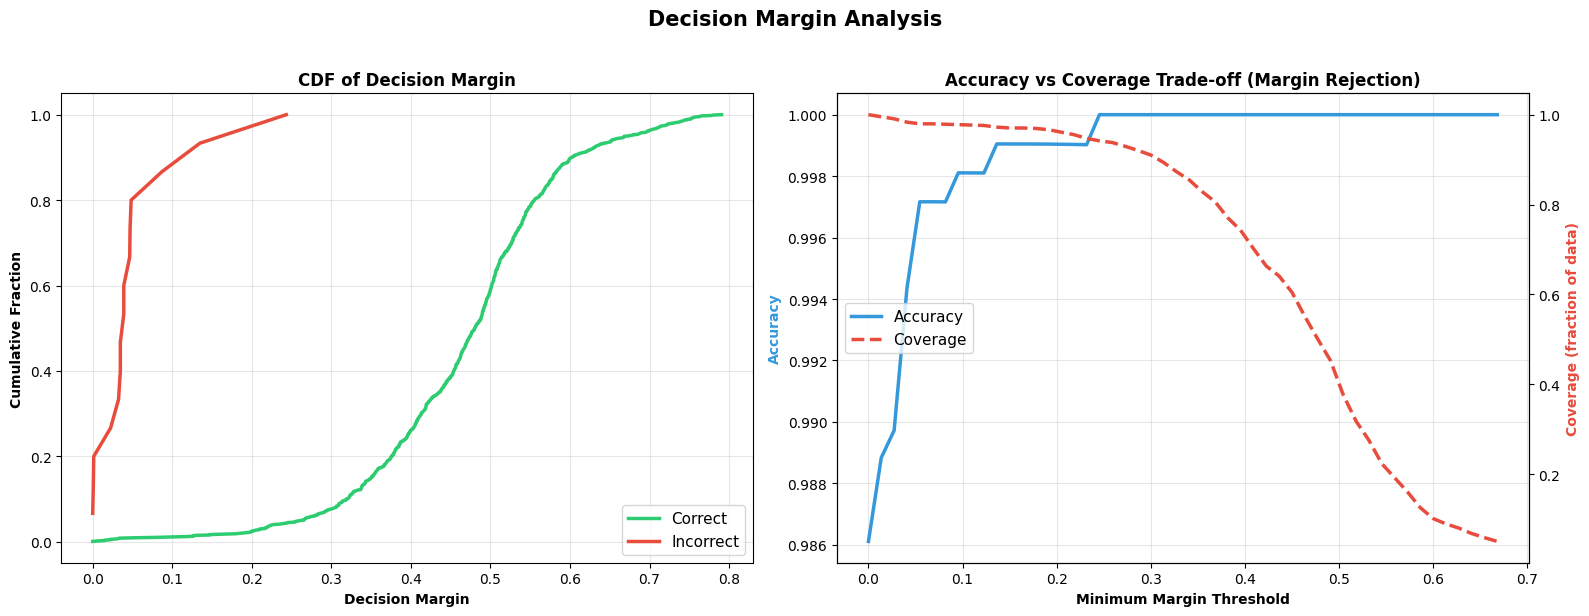


Margin statistics:
  All images:     mean=0.4620, median=0.4779
  Correct only:   mean=0.4678
  Incorrect only: mean=0.0541


In [14]:
# ── Margin Analysis: How confident is the model? ─────────────────────────────
print("=" * 90)
print("DECISION MARGIN ANALYSIS")
print("=" * 90)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Margin CDF — Correct vs Incorrect
ax = axes[0]
for subset, color, label in [(results_df["correct"], '#2ecc71', 'Correct'),
                               (~results_df["correct"], '#e74c3c', 'Incorrect')]:
    margins = results_df.loc[subset, "margin"].sort_values()
    cdf = np.arange(1, len(margins) + 1) / len(margins)
    ax.plot(margins, cdf, linewidth=2.5, color=color, label=label)
ax.set_xlabel('Decision Margin', fontweight='bold')
ax.set_ylabel('Cumulative Fraction', fontweight='bold')
ax.set_title('CDF of Decision Margin', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# 2. Accuracy vs margin threshold (reject low-margin predictions)
ax = axes[1]
margin_thresholds = np.linspace(0, results_df["margin"].quantile(0.95), 50)
acc_at_thresh = []
coverage_at_thresh = []
for t in margin_thresholds:
    mask = results_df["margin"] >= t
    n = mask.sum()
    if n > 0:
        acc_at_thresh.append(results_df.loc[mask, "correct"].mean())
        coverage_at_thresh.append(n / len(results_df))
    else:
        acc_at_thresh.append(np.nan)
        coverage_at_thresh.append(0.0)

ax.plot(margin_thresholds, acc_at_thresh, linewidth=2.5, color='#3498db', label='Accuracy')
ax2 = ax.twinx()
ax2.plot(margin_thresholds, coverage_at_thresh, linewidth=2.5, color='#e74c3c', linestyle='--', label='Coverage')
ax.set_xlabel('Minimum Margin Threshold', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold', color='#3498db')
ax2.set_ylabel('Coverage (fraction of data)', fontweight='bold', color='#e74c3c')
ax.set_title('Accuracy vs Coverage Trade-off (Margin Rejection)', fontweight='bold')
ax.grid(alpha=0.3)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='center left')

plt.suptitle('Decision Margin Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
margin_path = EXPERIMENT_DIR / "margin_analysis.png"
plt.savefig(margin_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {margin_path}")
plt.show()

# Print key margin statistics
print(f"\nMargin statistics:")
print(f"  All images:     mean={results_df['margin'].mean():.4f}, median={results_df['margin'].median():.4f}")
print(f"  Correct only:   mean={results_df.loc[results_df['correct'], 'margin'].mean():.4f}")
print(f"  Incorrect only: mean={results_df.loc[~results_df['correct'], 'margin'].mean():.4f}")


✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/precision_recall_curve.png


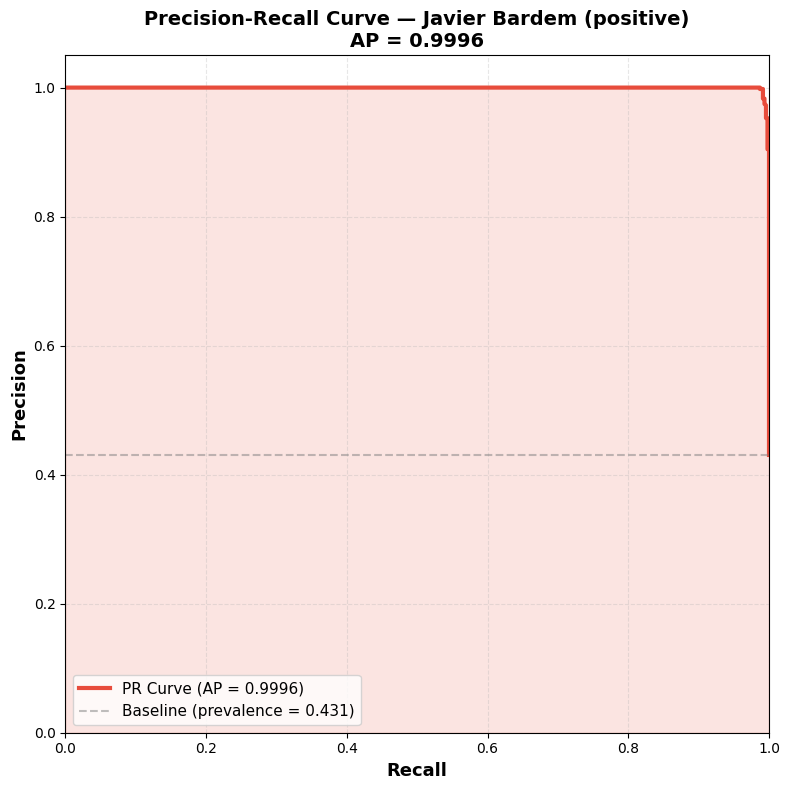


Average Precision (Javier Bardem): 0.9996
ROC AUC: 0.9997


In [15]:
# ── Precision-Recall Curve (binary) ───────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, average_precision_score

ap = average_precision_score(y_binary, score_diff)
prec_curve, rec_curve, thresholds_pr = precision_recall_curve(y_binary, score_diff)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(rec_curve, prec_curve, linewidth=3, color='#e74c3c', label=f'PR Curve (AP = {ap:.4f})')
ax.fill_between(rec_curve, prec_curve, alpha=0.15, color='#e74c3c')
ax.axhline(y=y_binary.mean(), color='gray', linestyle='--', linewidth=1.5, alpha=0.5,
           label=f'Baseline (prevalence = {y_binary.mean():.3f})')

ax.set_xlabel('Recall', fontsize=13, fontweight='bold')
ax.set_ylabel('Precision', fontsize=13, fontweight='bold')
ax.set_title(f'Precision-Recall Curve — Javier Bardem (positive)\nAP = {ap:.4f}', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11, loc='lower left')
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
pr_path = EXPERIMENT_DIR / "precision_recall_curve.png"
plt.savefig(pr_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {pr_path}")
plt.show()

print(f"\nAverage Precision (Javier Bardem): {ap:.4f}")
print(f"ROC AUC: {roc_auc_val:.4f}")


SCORE SEPARATION ANALYSIS
✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/score_separation.png


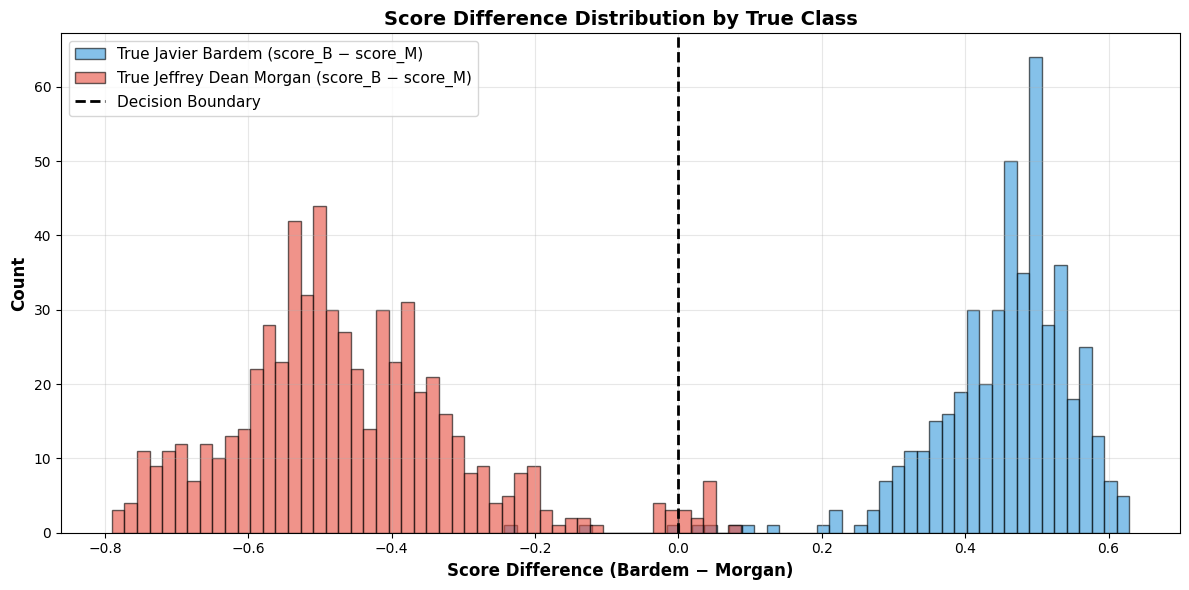


Overlap analysis:
  Javier Bardem images with score_B < score_M (misclassified): 0.4%
  Jeffrey Dean Morgan images with score_M < score_B (misclassified): 2.0%
  Mean score diff for true Bardem:  0.4549 ± 0.1003
  Mean score diff for true Morgan: 0.4648 ± 0.1589


In [16]:
# ── Score Calibration: How well-separated are the two classes? ────────────────
print("=" * 90)
print("SCORE SEPARATION ANALYSIS")
print("=" * 90)

bardem_mask   = y_true == "Javier Bardem"
morgan_mask   = y_true == "Jeffrey Dean Morgan"

# For each true-Bardem image, what is score_bardem - score_morgan?
bardem_diffs = results_df.loc[bardem_mask, "score_bardem"].values - results_df.loc[bardem_mask, "score_morgan"].values
morgan_diffs = results_df.loc[morgan_mask, "score_morgan"].values - results_df.loc[morgan_mask, "score_bardem"].values

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(bardem_diffs, bins=50, alpha=0.6, color='#3498db', edgecolor='black', label='True Javier Bardem (score_B − score_M)')
ax.hist(-morgan_diffs, bins=50, alpha=0.6, color='#e74c3c', edgecolor='black', label='True Jeffrey Dean Morgan (score_B − score_M)')
ax.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
ax.set_xlabel('Score Difference (Bardem − Morgan)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_title('Score Difference Distribution by True Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
sep_path = EXPERIMENT_DIR / "score_separation.png"
plt.savefig(sep_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {sep_path}")
plt.show()

# Quantify overlap: what fraction of each class falls on the wrong side?
bardem_wrong = (bardem_diffs < 0).mean()
morgan_wrong = (morgan_diffs < 0).mean()
print(f"\nOverlap analysis:")
print(f"  Javier Bardem images with score_B < score_M (misclassified): {bardem_wrong:.1%}")
print(f"  Jeffrey Dean Morgan images with score_M < score_B (misclassified): {morgan_wrong:.1%}")
print(f"  Mean score diff for true Bardem:  {bardem_diffs.mean():.4f} ± {bardem_diffs.std():.4f}")
print(f"  Mean score diff for true Morgan: {morgan_diffs.mean():.4f} ± {morgan_diffs.std():.4f}")


THRESHOLD SENSITIVITY ANALYSIS
✓ Saved: /app/image_outputs/insightface_lookalike_20260310_231658/threshold_sensitivity.png


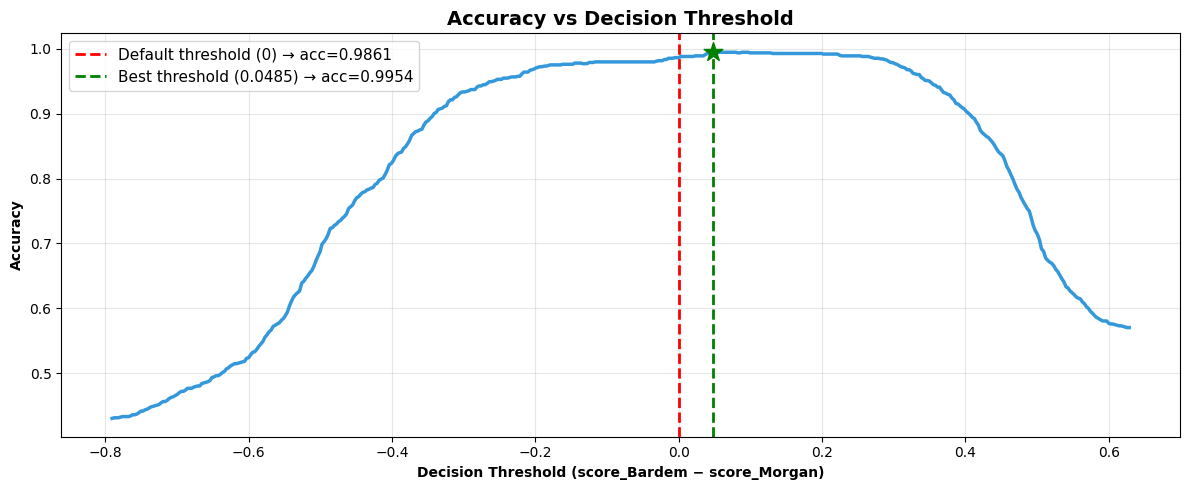


Default threshold (0):    accuracy = 0.9861
Optimal threshold (0.0485): accuracy = 0.9954
Improvement:               +0.93 pp


In [17]:
# ── Optimal threshold analysis ────────────────────────────────────────────────
# Instead of always using threshold=0, find the threshold on score_diff that maximises accuracy
print("=" * 90)
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 90)

thresholds_sweep = np.linspace(score_diff.min(), score_diff.max(), 500)
accs = []
for t in thresholds_sweep:
    pred_at_t = np.where(score_diff >= t, "Javier Bardem", "Jeffrey Dean Morgan")
    accs.append(accuracy_score(y_true, pred_at_t))

accs = np.array(accs)
best_idx = accs.argmax()
best_thresh = thresholds_sweep[best_idx]
best_acc = accs[best_idx]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thresholds_sweep, accs, linewidth=2.5, color='#3498db')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label=f'Default threshold (0) → acc={accuracy:.4f}')
ax.axvline(x=best_thresh, color='green', linestyle='--', linewidth=2, label=f'Best threshold ({best_thresh:.4f}) → acc={best_acc:.4f}')
ax.scatter(best_thresh, best_acc, s=200, color='green', zorder=5, marker='*')
ax.set_xlabel('Decision Threshold (score_Bardem − score_Morgan)', fontweight='bold')
ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Accuracy vs Decision Threshold', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
thresh_path = EXPERIMENT_DIR / "threshold_sensitivity.png"
plt.savefig(thresh_path, dpi=150, bbox_inches='tight')
print(f"✓ Saved: {thresh_path}")
plt.show()

print(f"\nDefault threshold (0):    accuracy = {accuracy:.4f}")
print(f"Optimal threshold ({best_thresh:.4f}): accuracy = {best_acc:.4f}")
print(f"Improvement:               +{(best_acc - accuracy)*100:.2f} pp")


In [18]:
# ── Hardest examples: images where the model was most confused ────────────────
print("=" * 90)
print("HARDEST EXAMPLES (lowest margins among misclassifications)")
print("=" * 90)

errors_sorted = results_df[~results_df["correct"]].sort_values("margin")

print(f"\nTop 20 hardest misclassifications (lowest margin):\n")
print(f"{'#':<4} {'True Label':<25} {'Predicted':<25} {'Score_B':>8} {'Score_M':>8} {'Margin':>8}")
print("─" * 90)

for i, (idx, row) in enumerate(errors_sorted.head(20).iterrows()):
    img_path = test_items[idx]["path"] if idx < len(test_items) else "?"
    print(f"{i+1:<4} {row['true_label']:<25} {row['pred_label']:<25} "
          f"{row['score_bardem']:>8.4f} {row['score_morgan']:>8.4f} {row['margin']:>8.4f}")

# Also show easiest correct predictions (highest margins)
print(f"\n{'─' * 90}")
print(f"Top 10 easiest correct predictions (highest margin):\n")
correct_sorted = results_df[results_df["correct"]].sort_values("margin", ascending=False)
print(f"{'#':<4} {'True Label':<25} {'Predicted':<25} {'Score_B':>8} {'Score_M':>8} {'Margin':>8}")
print("─" * 90)
for i, (idx, row) in enumerate(correct_sorted.head(10).iterrows()):
    print(f"{i+1:<4} {row['true_label']:<25} {row['pred_label']:<25} "
          f"{row['score_bardem']:>8.4f} {row['score_morgan']:>8.4f} {row['margin']:>8.4f}")


HARDEST EXAMPLES (lowest margins among misclassifications)

Top 20 hardest misclassifications (lowest margin):

#    True Label                Predicted                  Score_B  Score_M   Margin
──────────────────────────────────────────────────────────────────────────────────────────
1    Jeffrey Dean Morgan       Javier Bardem               0.0000   0.0000   0.0000
2    Jeffrey Dean Morgan       Javier Bardem               0.1277   0.1269   0.0008
3    Jeffrey Dean Morgan       Javier Bardem               0.0173   0.0160   0.0013
4    Jeffrey Dean Morgan       Javier Bardem               0.1174   0.0949   0.0225
5    Jeffrey Dean Morgan       Javier Bardem               0.1047   0.0723   0.0325
6    Jeffrey Dean Morgan       Javier Bardem               0.0887   0.0540   0.0347
7    Jeffrey Dean Morgan       Javier Bardem               0.0887   0.0540   0.0347
8    Jeffrey Dean Morgan       Javier Bardem               0.1534   0.1143   0.0391
9    Jeffrey Dean Morgan       Javier Bar

# Comprehensive Summary Dashboard


/tmp/ipykernel_47741/3472418512.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


✓ Dashboard saved: /app/image_outputs/insightface_lookalike_20260310_231658/00_dashboard.png


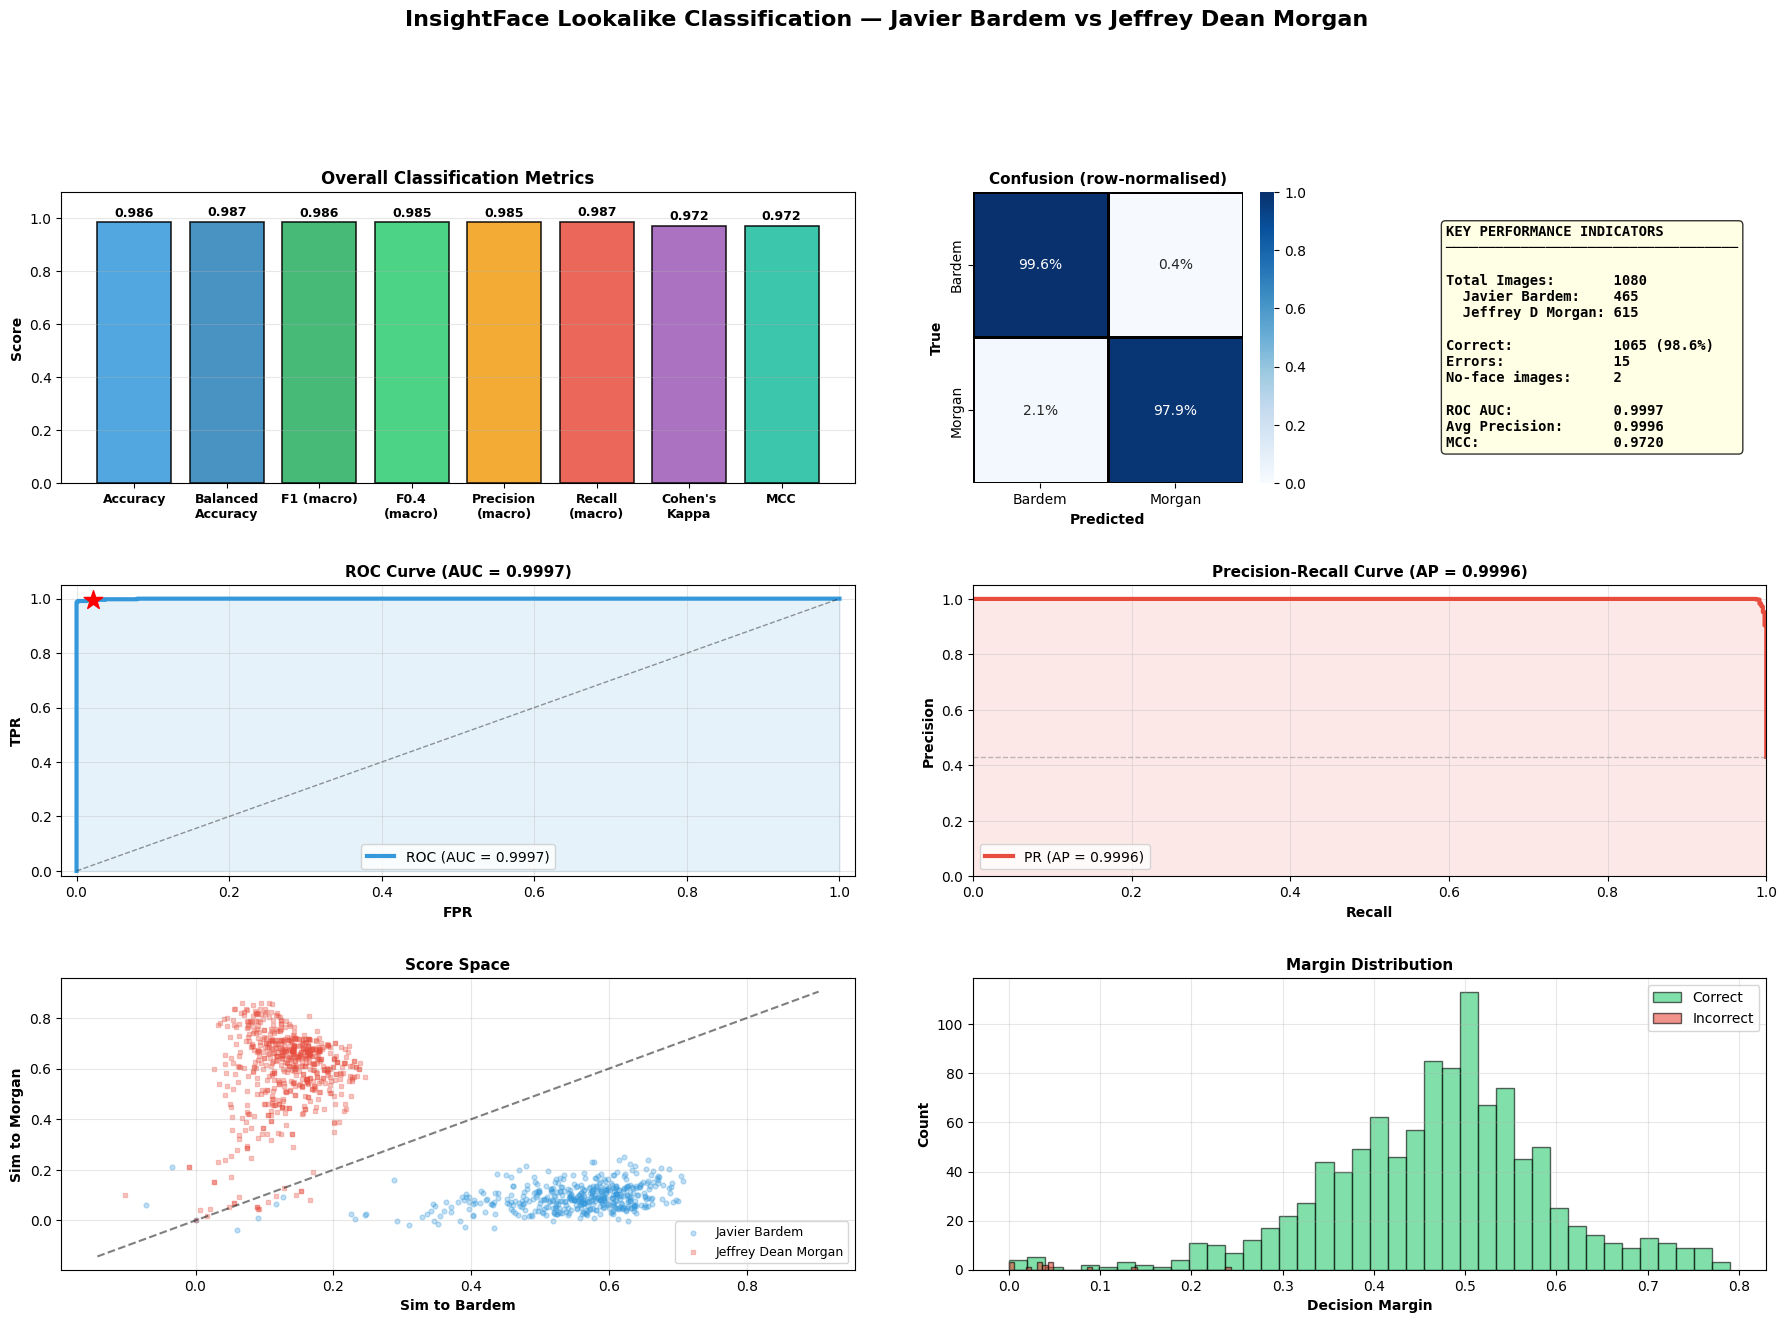

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE SUMMARY DASHBOARD
# ═══════════════════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 4, hspace=0.35, wspace=0.35)

# ── 1. Overall metrics bar chart ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0:2])
overall_metrics = {
    'Accuracy': accuracy,
    'Balanced\nAccuracy': balanced_acc,
    'F1 (macro)': f1_macro,
    'F0.4\n(macro)': f04_macro,
    'Precision\n(macro)': precision_macro,
    'Recall\n(macro)': recall_macro,
    "Cohen's\nKappa": kappa,
    'MCC': mcc,
}
colors_bar = ['#3498db', '#2980b9', '#27ae60', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
bars = ax1.bar(range(len(overall_metrics)), list(overall_metrics.values()),
               color=colors_bar, alpha=0.85, edgecolor='black', linewidth=1.2)
ax1.set_xticks(range(len(overall_metrics)))
ax1.set_xticklabels(overall_metrics.keys(), fontsize=9, fontweight='bold')
for bar, v in zip(bars, overall_metrics.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{v:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
ax1.set_ylim([-0.1 if mcc < 0 else 0, 1.1])
ax1.set_ylabel('Score', fontweight='bold')
ax1.set_title('Overall Classification Metrics', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# ── 2. Confusion matrix ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=['Bardem', 'Morgan'], yticklabels=['Bardem', 'Morgan'],
            ax=ax2, vmin=0, vmax=1, linewidths=1, linecolor='black')
ax2.set_xlabel('Predicted', fontweight='bold')
ax2.set_ylabel('True', fontweight='bold')
ax2.set_title('Confusion (row-normalised)', fontweight='bold', fontsize=11)

# ── 3. KPIs text ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 3])
ax3.axis('off')
kpi_text = (
    f"KEY PERFORMANCE INDICATORS\n"
    f"{'─' * 35}\n\n"
    f"Total Images:       {len(results_df)}\n"
    f"  Javier Bardem:    {(y_true == 'Javier Bardem').sum()}\n"
    f"  Jeffrey D Morgan: {(y_true == 'Jeffrey Dean Morgan').sum()}\n\n"
    f"Correct:            {results_df['correct'].sum()} ({accuracy:.1%})\n"
    f"Errors:             {(~results_df['correct']).sum()}\n"
    f"No-face images:     {no_face_count}\n\n"
    f"ROC AUC:            {roc_auc_val:.4f}\n"
    f"Avg Precision:      {ap:.4f}\n"
    f"MCC:                {mcc:.4f}"
)
ax3.text(0.05, 0.5, kpi_text, fontsize=10, family='monospace', fontweight='bold',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── 4. ROC curve ─────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
ax4.plot(fpr, tpr, linewidth=3, color='#3498db', label=f'ROC (AUC = {roc_auc_val:.4f})')
ax4.fill_between(fpr, tpr, alpha=0.12, color='#3498db')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4)
ax4.scatter(op_fpr_val, op_tpr, s=200, color='red', marker='*', zorder=5)
ax4.set_xlabel('FPR', fontweight='bold'); ax4.set_ylabel('TPR', fontweight='bold')
ax4.set_title(f'ROC Curve (AUC = {roc_auc_val:.4f})', fontweight='bold', fontsize=11)
ax4.legend(fontsize=10); ax4.grid(alpha=0.3); ax4.set_xlim([-0.02, 1.02]); ax4.set_ylim([-0.02, 1.05])

# ── 5. PR curve ──────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2:4])
ax5.plot(rec_curve, prec_curve, linewidth=3, color='#e74c3c', label=f'PR (AP = {ap:.4f})')
ax5.fill_between(rec_curve, prec_curve, alpha=0.12, color='#e74c3c')
ax5.axhline(y=y_binary.mean(), color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax5.set_xlabel('Recall', fontweight='bold'); ax5.set_ylabel('Precision', fontweight='bold')
ax5.set_title(f'Precision-Recall Curve (AP = {ap:.4f})', fontweight='bold', fontsize=11)
ax5.legend(fontsize=10); ax5.grid(alpha=0.3); ax5.set_xlim([0, 1]); ax5.set_ylim([0, 1.05])

# ── 6. Score scatter ─────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 0:2])
for label, marker, color in zip(TARGET_IDENTITIES, ['o', 's'], ['#3498db', '#e74c3c']):
    mask = results_df["true_label"] == label
    ax6.scatter(results_df.loc[mask, "score_bardem"], results_df.loc[mask, "score_morgan"],
                alpha=0.3, s=12, marker=marker, color=color, label=label)
lims = [min(ax6.get_xlim()[0], ax6.get_ylim()[0]), max(ax6.get_xlim()[1], ax6.get_ylim()[1])]
ax6.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5)
ax6.set_xlabel('Sim to Bardem', fontweight='bold'); ax6.set_ylabel('Sim to Morgan', fontweight='bold')
ax6.set_title('Score Space', fontweight='bold', fontsize=11)
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# ── 7. Margin histogram ─────────────────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2:4])
ax7.hist(results_df.loc[results_df["correct"], "margin"], bins=40, alpha=0.6,
         color='#2ecc71', edgecolor='black', label='Correct')
ax7.hist(results_df.loc[~results_df["correct"], "margin"], bins=40, alpha=0.6,
         color='#e74c3c', edgecolor='black', label='Incorrect')
ax7.set_xlabel('Decision Margin', fontweight='bold'); ax7.set_ylabel('Count', fontweight='bold')
ax7.set_title('Margin Distribution', fontweight='bold', fontsize=11)
ax7.legend(fontsize=10); ax7.grid(alpha=0.3)

fig.suptitle('InsightFace Lookalike Classification — Javier Bardem vs Jeffrey Dean Morgan',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
dashboard_path = EXPERIMENT_DIR / "00_dashboard.png"
plt.savefig(dashboard_path, dpi=150, bbox_inches='tight')
print(f"✓ Dashboard saved: {dashboard_path}")
plt.show()


# Executive Summary


In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# EXECUTIVE SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print(f"""
{'=' * 90}
 INSIGHTFACE LOOKALIKE CLASSIFICATION — EXECUTIVE SUMMARY
{'=' * 90}

 Task:   Distinguish Javier Bardem from Jeffrey Dean Morgan
 Model:  InsightFace (buffalo_l) – cosine similarity to single reference per person
 Rule:   Assign label with maximum similarity (no threshold, no "unknown" class)

 Test Set:
   Total images:       {len(results_df)}
   Javier Bardem:      {(y_true == 'Javier Bardem').sum()} images ({(y_true == 'Javier Bardem').mean():.1%})
   Jeffrey Dean Morgan:{(y_true == 'Jeffrey Dean Morgan').sum()} images ({(y_true == 'Jeffrey Dean Morgan').mean():.1%})
   No face detected:   {no_face_count} images

{'─' * 90}
 RESULTS
{'─' * 90}
   Accuracy:               {accuracy:.4f}  ({results_df['correct'].sum()}/{len(results_df)} correct)
   Balanced Accuracy:      {balanced_acc:.4f}
   Precision (macro):      {precision_macro:.4f}
   Recall (macro):         {recall_macro:.4f}
   F1 Score (macro):       {f1_macro:.4f}
   F0.4 Score (macro):     {f04_macro:.4f}
   Cohen's Kappa:          {kappa:.4f}
   Matthews Corr Coeff:    {mcc:.4f}
   ROC AUC:                {roc_auc_val:.4f}
   Average Precision:      {ap:.4f}

{'─' * 90}
 PER-CLASS BREAKDOWN
{'─' * 90}
   {'Class':<25} {'Precision':>10} {'Recall':>10} {'F0.4':>10} {'F1':>10} {'Support':>10}
   {'─' * 65}""")

for label in TARGET_IDENTITIES:
    m = per_class[label]
    print(f"   {label:<25} {m['Precision']:>10.4f} {m['Recall']:>10.4f} {m['F0.4']:10.4f} {m['F1']:>10.4f} {m['Support']:>10}")

print(f"""
{'─' * 90}
 CONFIDENCE ANALYSIS
{'─' * 90}
   Mean decision margin (all):       {results_df['margin'].mean():.4f}
   Mean margin (correct):            {results_df.loc[results_df['correct'], 'margin'].mean():.4f}
   Mean margin (incorrect):          {results_df.loc[~results_df['correct'], 'margin'].mean():.4f}
   Optimal threshold shift:          {best_thresh:.4f} (→ best acc {best_acc:.4f}, +{(best_acc - accuracy)*100:.2f}pp)

{'─' * 90}
 GENERATED VISUALIZATIONS
{'─' * 90}
   1. 00_dashboard.png              — Full summary dashboard
   2. confusion_matrix.png          — Confusion matrix (counts & normalised)
   3. similarity_distributions.png  — Score distributions and scatter
   4. roc_curve.png                 — ROC curve with operating point
   5. precision_recall_curve.png    — Precision-Recall curve
   6. per_class_performance.png     — Per-class bar charts
   7. margin_analysis.png           — Decision margin analysis
   8. score_separation.png          — Score difference distributions
   9. threshold_sensitivity.png     — Accuracy vs threshold sweep

   All outputs: {EXPERIMENT_DIR}

{'=' * 90}
 EVALUATION COMPLETE
{'=' * 90}
""")



 INSIGHTFACE LOOKALIKE CLASSIFICATION — EXECUTIVE SUMMARY

 Task:   Distinguish Javier Bardem from Jeffrey Dean Morgan
 Model:  InsightFace (buffalo_l) – cosine similarity to single reference per person
 Rule:   Assign label with maximum similarity (no threshold, no "unknown" class)

 Test Set:
   Total images:       1080
   Javier Bardem:      465 images (43.1%)
   Jeffrey Dean Morgan:615 images (56.9%)
   No face detected:   2 images

──────────────────────────────────────────────────────────────────────────────────────────
 RESULTS
──────────────────────────────────────────────────────────────────────────────────────────
   Accuracy:               0.9861  (1065/1080 correct)
   Balanced Accuracy:      0.9873
   Precision (macro):      0.9847
   Recall (macro):         0.9873
   F1 Score (macro):       0.9859
   F0.4 Score (macro):     0.9850
   Cohen's Kappa:          0.9718
   Matthews Corr Coeff:    0.9720
   ROC AUC:                0.9997
   Average Precision:      0.9996

─────

In [21]:
# ── Save results to JSON ──────────────────────────────────────────────────────
import json

summary = {
    "experiment": "InsightFace Lookalike Classification",
    "testset": str(TESTSET_PATH),
    "identities": TARGET_IDENTITIES,
    "total_images": len(results_df),
    "no_face_count": no_face_count,
    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_acc),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "cohens_kappa": float(kappa),
    "mcc": float(mcc),
    "roc_auc": float(roc_auc_val),
    "average_precision": float(ap),
    "per_class": {
        label: {k: float(v) if isinstance(v, (np.floating, float)) else int(v)
                for k, v in metrics.items()}
        for label, metrics in per_class.items()
    },
    "margin_stats": {
        "mean": float(results_df["margin"].mean()),
        "median": float(results_df["margin"].median()),
        "std": float(results_df["margin"].std()),
    },
    "optimal_threshold": float(best_thresh),
    "optimal_threshold_accuracy": float(best_acc),
}

results_json_path = EXPERIMENT_DIR / "results_summary.json"
with open(results_json_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"✓ Results saved to: {results_json_path}")


✓ Results saved to: /app/image_outputs/insightface_lookalike_20260310_231658/results_summary.json


In [22]:
# ── Requested metrics summary: macro + per-class, including R@P=0.95 ─────────
from sklearn.metrics import roc_auc_score, precision_recall_curve


def recall_at_precision(y_true_binary, y_score, min_precision=0.95):
    precision_vals, recall_vals, _ = precision_recall_curve(y_true_binary, y_score)
    valid = precision_vals >= min_precision
    if not np.any(valid):
        return 0.0
    return float(np.max(recall_vals[valid]))


per_class_extended = {}
score_by_class = {
    "Javier Bardem": results_df["score_bardem"].values - results_df["score_morgan"].values,
    "Jeffrey Dean Morgan": results_df["score_morgan"].values - results_df["score_bardem"].values,
}

for label in TARGET_IDENTITIES:
    y_true_binary = (y_true == label).astype(int)
    y_pred_binary = (y_pred == label).astype(int)
    tp = int(np.sum((y_true_binary == 1) & (y_pred_binary == 1)))
    fp = int(np.sum((y_true_binary == 0) & (y_pred_binary == 1)))
    fn = int(np.sum((y_true_binary == 1) & (y_pred_binary == 0)))
    tn = int(np.sum((y_true_binary == 0) & (y_pred_binary == 0)))

    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    accuracy_val = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
    beta2 = F1_BETA ** 2
    f04_val = ((1 + beta2) * precision_val * recall_val / (beta2 * precision_val + recall_val)
               if (precision_val + recall_val) > 0 else 0.0)
    roc_auc_class = float(roc_auc_score(y_true_binary, score_by_class[label]))
    recall_at_p95 = recall_at_precision(y_true_binary, score_by_class[label], FIXED_PRECISION_LEVEL)

    per_class_extended[label] = {
        "Accuracy": float(accuracy_val),
        "Precision": float(precision_val),
        "Recall": float(recall_val),
        "F0.4": float(f04_val),
        "ROC AUC": roc_auc_class,
        "R@P=0.95": recall_at_p95,
        "Support": int(np.sum(y_true_binary)),
    }

macro_metrics_requested = {
    "Accuracy": float(np.mean([m["Accuracy"] for m in per_class_extended.values()])),
    "Precision": float(np.mean([m["Precision"] for m in per_class_extended.values()])),
    "Recall": float(np.mean([m["Recall"] for m in per_class_extended.values()])),
    "F0.4": float(np.mean([m["F0.4"] for m in per_class_extended.values()])),
    "ROC AUC": float(np.mean([m["ROC AUC"] for m in per_class_extended.values()])),
    "R@P=0.95": float(np.mean([m["R@P=0.95"] for m in per_class_extended.values()])),
}

requested_metrics_df = pd.DataFrame(per_class_extended).T[["Accuracy", "Precision", "Recall", "F0.4", "ROC AUC", "R@P=0.95", "Support"]]

print("=" * 90)
print("REQUESTED METRICS SUMMARY")
print("=" * 90)
print("\nMacro metrics:")
for metric_name, metric_value in macro_metrics_requested.items():
    print(f"  {metric_name:<10} {metric_value:.4f}")

print("\nPer-class metrics:")
print(requested_metrics_df.to_string(float_format=lambda value: f"{value:.4f}"))

REQUESTED METRICS SUMMARY

Macro metrics:
  Accuracy   0.9861
  Precision  0.9847
  Recall     0.9873
  F0.4       0.9850
  ROC AUC    0.9997
  R@P=0.95   0.9989

Per-class metrics:
                     Accuracy  Precision  Recall   F0.4  ROC AUC  R@P=0.95  Support
Javier Bardem          0.9861     0.9727  0.9957 0.9758   0.9997    0.9978 465.0000
Jeffrey Dean Morgan    0.9861     0.9967  0.9789 0.9942   0.9997    1.0000 615.0000
